In [55]:
import os, sys
sys.path.append(os.path.join(os.environ.get('IDEFIX_DIR','../../../../'), 'pytools'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import dump_io as io

import pickle as pk
from astropy import constants as const, units as u

%matplotlib inline


In [56]:
dirc = 'out/'

def load(dirc=dirc, i=0, var='Vc-RHO', slicer=np.s_[:]): return io.readDump(f'{dirc}/dump.{i:04d}.dmp').data[var].transpose(2,1,0)[slicer][0]
def load3D(dirc=dirc, i=0, var='Vc-RHO', slicer=np.s_[:]): return io.readDump(f'{dirc}/dump.{i:04d}.dmp').data[var].transpose(2,1,0)[slicer]

snap = 10

In [57]:
dmp = io.readDump(f'{dirc}/dump.0000.dmp')
r, th, phi = dmp.x1, dmp.x2, dmp.x3


uL = 1e8 *u.cm.cgs
uM = 1e24*u.g.cgs
uv = 1e5*u.cm.cgs/u.s.cgs
uT = ((u.g.cgs/u.mol.cgs) * uv**2 / (const.k_B.cgs * const.N_A.cgs)).decompose()
ud = uM/uL**3

mu = 2.353

u_aR = (uM*uv**2/(uL**3 * uT**4)).decompose()
aR = ((4*const.sigma_sb/const.c)/u_aR ).to_value()

sig = 0.25*aR*3e5


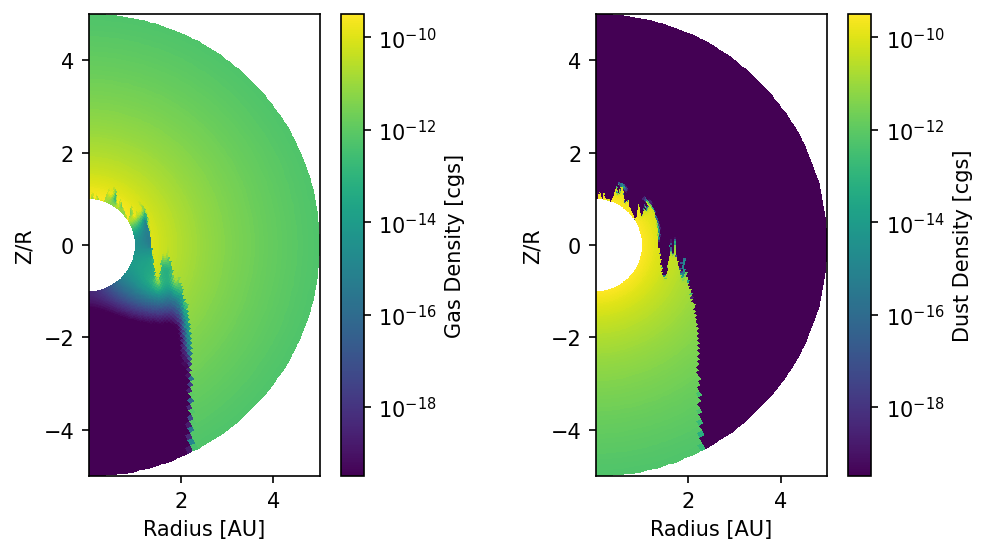

In [58]:
fig, ax = plt.subplots(1, 2, dpi=150, figsize=(8,4))
ax[0].set_aspect('equal')
ax[1].set_aspect('equal')

rho = load(i=snap, var='Vc-RHO')
rho_d = load(i=snap, var='Dust0_Vc-RHO')


z = r*np.cos(th[:,None])
x = r*np.sin(th[:,None])


im = ax[0].pcolormesh(x, z, rho * ud.to_value('g/cm**3'), norm=LogNorm(vmin=1e-10*rho.max() *ud.to_value('g/cm**3')))
ax[0].set_xlabel('Radius [AU]')
ax[0].set_ylabel('Z/R')
fig.colorbar(im, ax=ax[0], label='Gas Density [cgs]')


im = ax[1].pcolormesh(x, z, rho_d * ud.to_value('g/cm**3'), norm=LogNorm(vmin=1e-10*rho_d.max() *ud.to_value('g/cm**3')))
ax[1].set_xlabel('Radius [AU]')
ax[1].set_ylabel('Z/R')
fig.colorbar(im, ax=ax[1], label='Dust Density [cgs]')


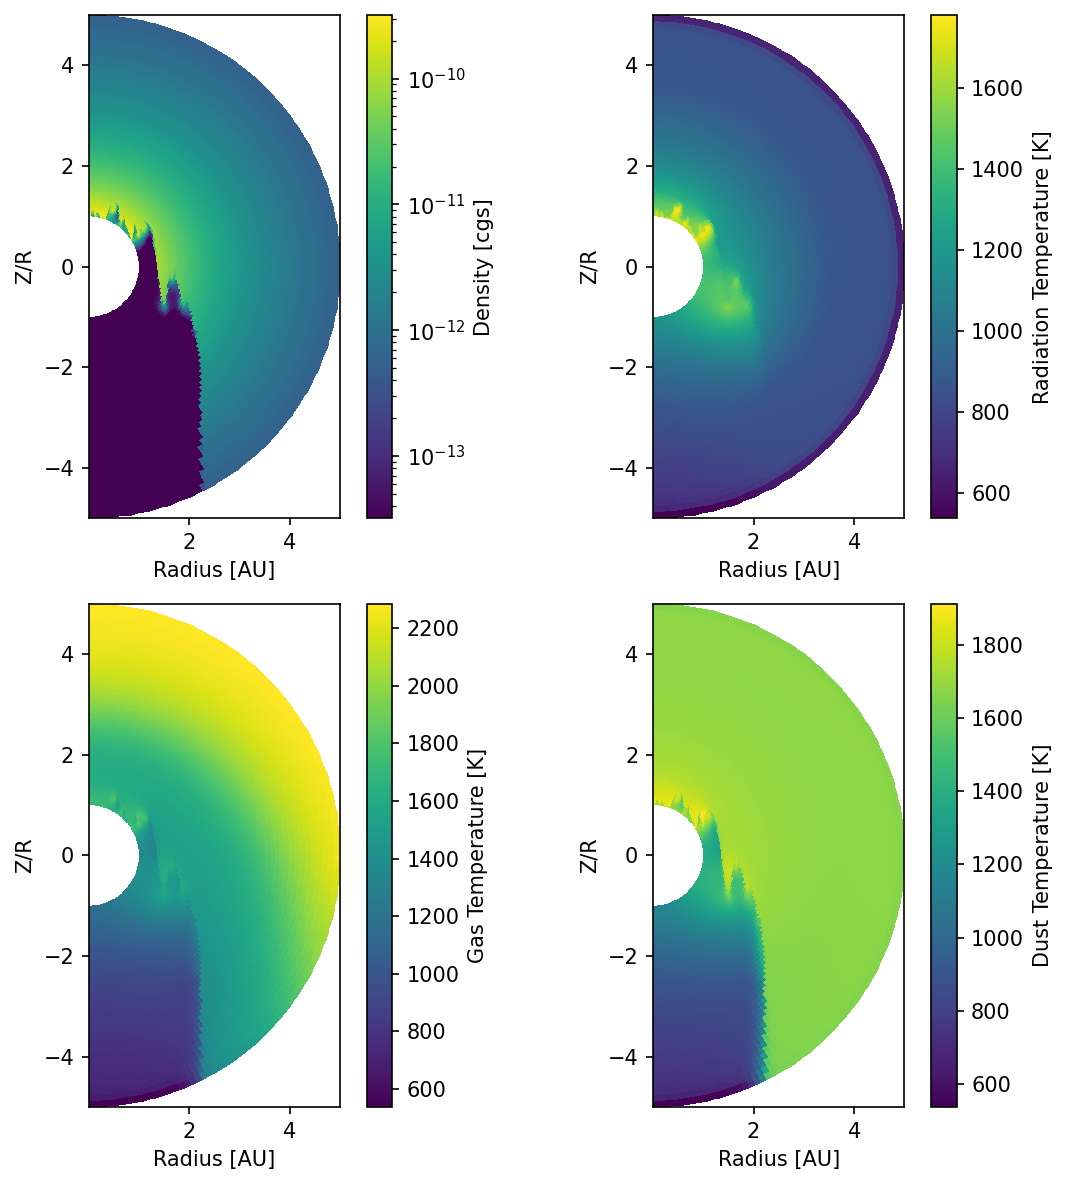

In [59]:
fig, ax = plt.subplots(2, 2, dpi=150, figsize=(8,8))
ax[0,0].set_aspect('equal')
ax[0,1].set_aspect('equal')
ax[1,0].set_aspect('equal')
ax[1,1].set_aspect('equal')



rho = load(i=snap, var='Vc-RHO')
P = load(i=snap, var='Vc-PRS')
Er = load(i=snap, var='ERAD')

Tr = (Er/aR)**0.25 

T = mu * (P/rho)

z = r*np.cos(th[:,None])
x = r*np.sin(th[:,None])

im = ax[0,0].pcolormesh(x, z, rho * ud.to_value('g/cm**3'), norm=LogNorm(vmin=1e-4*rho.max() *ud.to_value('g/cm**3')))
ax[0,0].set_xlabel('Radius [AU]')
ax[0,0].set_ylabel('Z/R')
fig.colorbar(im, ax=ax[0,0], label='Density [cgs]')

im = ax[0,1].pcolormesh(x, z, Tr * uT.to_value('K'))
ax[0,1].set_xlabel('Radius [AU]')
ax[0,1].set_ylabel('Z/R')
fig.colorbar(im, ax=ax[0,1], label='Radiation Temperature [K]')

im = ax[1,0].pcolormesh(x, z, T * uT.to_value('K'))
ax[1,0].set_xlabel('Radius [AU]')
ax[1,0].set_ylabel('Z/R')
fig.colorbar(im, ax=ax[1,0], label='Gas Temperature [K]')


try:
    rho = load(i=snap, var='Dust0_Vc-RHO')
    P = load(i=snap, var='Dust0_Vc-TR0')
    T = P/rho
    im = ax[1,1].pcolormesh(x, z, T * uT.to_value('K'))
    ax[1,1].set_xlabel('Radius [AU]')
    ax[1,1].set_ylabel('Z/R')
    fig.colorbar(im, ax=ax[1,1], label='Dust Temperature [K]')
except KeyError:
    pass
fig.tight_layout()


Maximum surface temperature: 2360.717812014131
Maximum Dust temperature: 1912.7834944813264


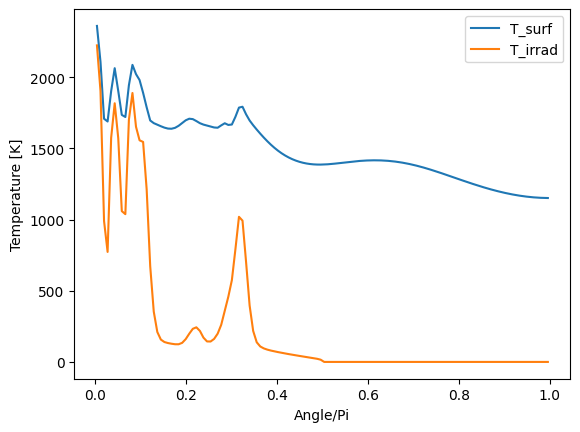

In [60]:
surf = np.genfromtxt('out/surface.txt').reshape(-1, th.shape[0], 4)
print('Maximum surface temperature:', surf[:,:,2].max() * uT.to_value('K'))
print('Maximum Dust temperature:', T.max() * uT.to_value('K'))

plt.plot(th/np.pi, surf[0,:,2] * uT.to_value('K'), label='T_surf')
plt.plot(th/np.pi, (-surf[0,:,3]/sig)**0.25 * uT.to_value('K'), label='T_irrad')
plt.xlabel('Angle/Pi')
plt.ylabel('Temperature [K]')
plt.legend()